In [2]:
#pip install scipy

In [1]:
from sympy.stats.sampling.sample_scipy import scipy

import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import entropy, permutation_test, linregress


In [2]:
infile= "b14_big_SN_combined_288-good.csv"

col = np.loadtxt("scraper/eval/b14/"+infile, delimiter="\t", usecols=3, skiprows=1, dtype=int)

col1= np.array(col[1:289])
col2= np.array(col[290:])



print(col1)
print(col[289])
rel_col1 = col1/col[0]
rel_col2 = col2/col[289]
print(rel_col1)

[16900   230  2815   205  2415    45   361    29   141     1    18     2
    16     0     1     0     0     0     0     0     0     0     0     0
   445    11    19     2    71     2     2     0     3     0     0     0
     1     0     0     0     0     0     0     0     0     0     0     0
     1     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
 33139  2241    42     4  7516   576     7     0   542    17     0     0
    11     1     0     0     1     0     0     0     0     0     0     0
  1755   157     3     0   286    53     0     0    21     2     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     1     0     0     0     1     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
   785    35     0     0   149     9     0     0     5     0     0     0
     0     0     0     0     0     0     0     0   

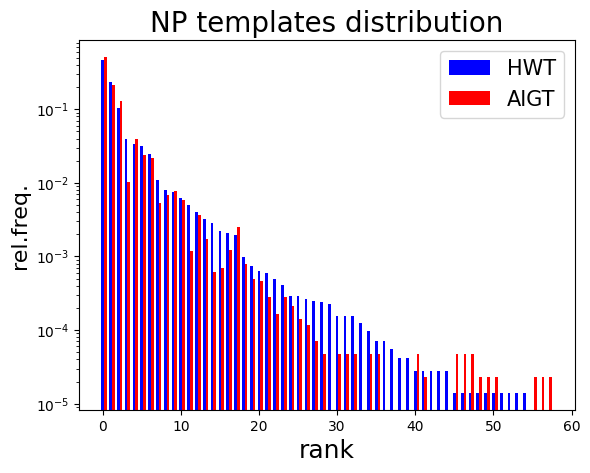

58


In [3]:
# PLOTTING col1 and col2

mask = (col2 >= 1) | (col1 >= 1)

pos_rel_col1 = rel_col1[mask]
pos_rel_col2 = rel_col2[mask]
z= list(zip(pos_rel_col1, pos_rel_col2))
z.sort(reverse=True)

s_pos_col1= np.array([i[0] for i in z])
s_pos_col2= np.array([i[1] for i in z])

rank_col1 = [i+0.00000001 for i in range(len(pos_rel_col1))]


barWidth = 0.35
br1 = np.arange(len(rank_col1))
br2 = [x + barWidth for x in br1]


plt.title("NP templates distribution", fontsize=20)
plt.bar(br1, s_pos_col1, width= barWidth, color='b', label='HWT')
plt.bar(br2, s_pos_col2, width= barWidth, color='r', label='AIGT')
plt.legend( loc='best', fontsize=15)
plt.xlabel('rank', fontsize=18)
plt.ylabel('rel.freq.', fontsize=16)

plt.semilogy()
plt.show()

print(len(s_pos_col1))


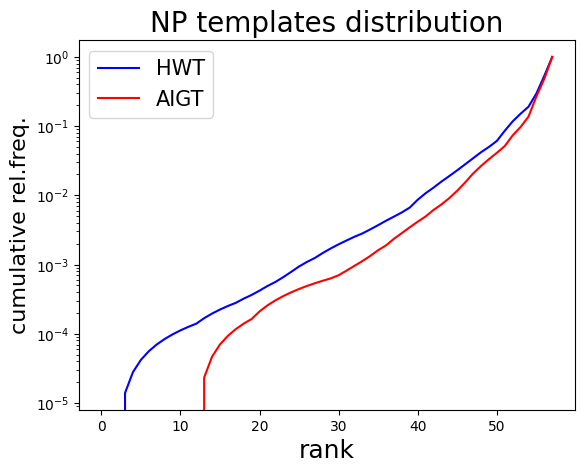

In [4]:
# CUMULATIVE PLOTTING OF col1 and col2

mask = (col2 >= 1) | (col1 >= 1)

pos_rel_col1 = rel_col1[mask]
pos_rel_col2 = rel_col2[mask]


s_rel_col1= np.sort(pos_rel_col1)
s_rel_col2= np.sort(pos_rel_col2)

#evaluate the cumulative
cumulative = np.cumsum(s_rel_col1)
cumulative2 = np.cumsum(s_rel_col2)

# Cumulat
plt.title("NP templates distribution", fontsize=20)

# plot the cumulative function
plt.plot(list(range(len(cumulative))), cumulative,   c='b', label="HWT")
#plot the survival function
plt.plot(list(range(len(cumulative2))), cumulative2,   c='r', label="AIGT")
plt.legend( loc='best', fontsize=15)
plt.xlabel('rank', fontsize=18)
plt.ylabel('cumulative rel.freq.', fontsize=16)
plt.semilogy()
plt.show()



a = 1.2013777512164856 b = 1.1188573358954454


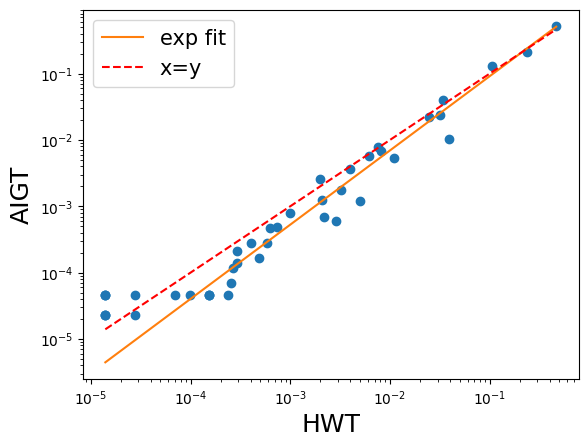

res 0.21360920639410305
0.21360920639410305


In [21]:
# GOOD ENOUGH: attempt to power-law the relation between the two amounts

import numpy as np
from scipy.optimize import curve_fit

# power law model
def power_law(x, a, b):
    return a * x**b

# FER HO RELATIUUU

# remove neg vals
mask = (col1 > 0) & (col2 > 0)
pos_col1 = col1[mask]
pos_col2 = col2[mask]


# fit
params, cov = curve_fit(power_law, rel_col1, rel_col2)
a, b = params

print("a =", a, "b =", b)

# plot
x_fit = np.linspace(min(rel_col1[mask]), max(rel_col1), 100)
y_fit = power_law(x_fit, a, b)
#plt.title("NP templates", fontsize=20)
plt.xlabel("HWT", fontsize=18)
plt.ylabel("AIGT", fontsize=18)
plt.loglog(rel_col1, rel_col2, 'o')
plt.loglog(x_fit, y_fit, label="exp fit")
plt.loglog(x_fit, x_fit,color='red', label="x=y", ls="--")
plt.legend( loc='best', fontsize=15)
plt.show()
res=a**(1/(1-b))
print("res", res)
print(a*res**b)

Slope: 0.6407526704047857
Intercept: -10.198959918659796
R-squared: 0.9896330015221624


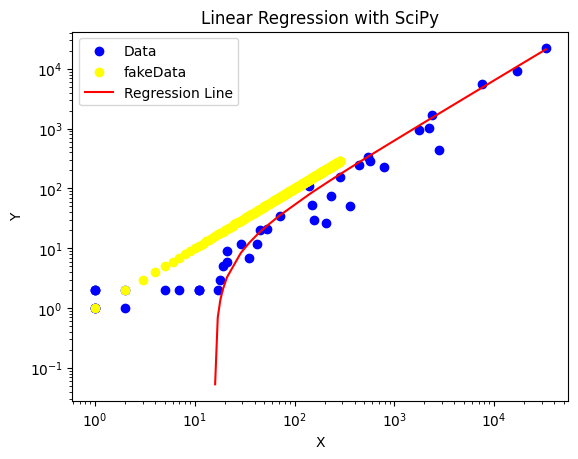

In [6]:
#   lin regression


slope, intercept, r_value, p_value, std_err = linregress(col1, col2)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

plt.scatter(col1, col2, color='blue', label='Data')
#plt.plot(col1, slope * col1 + intercept, color='red', label='Regression Line')
a= np.arange(len(col1))
plt.scatter(a, a, color='yellow', label='fakeData')
sort1= np.sort(col1)
sort1_pos = sort1[slope * sort1 + intercept>0]
plt.plot(sort1_pos, slope * sort1_pos + intercept, color='red', label='Regression Line')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression with SciPy")
plt.show()

In [7]:
sa = np.repeat(np.arange(len(col1)), col1)
b = np.repeat(np.arange(len(col2)), col2)

bins = np.arange(0, len(col1)+1)

hist_x, _ = np.histogram(a, bins=bins, density=True)

In [8]:
print(col1)

[16900   230  2815   205  2415    45   361    29   141     1    18     2
    16     0     1     0     0     0     0     0     0     0     0     0
   445    11    19     2    71     2     2     0     3     0     0     0
     1     0     0     0     0     0     0     0     0     0     0     0
     1     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
 33139  2241    42     4  7516   576     7     0   542    17     0     0
    11     1     0     0     1     0     0     0     0     0     0     0
  1755   157     3     0   286    53     0     0    21     2     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     1     0     0     0     1     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
   785    35     0     0   149     9     0     0     5     0     0     0
     0     0     0     0     0     0     0     0   

a = 1.2013777512164856 b = 1.1188573358954454


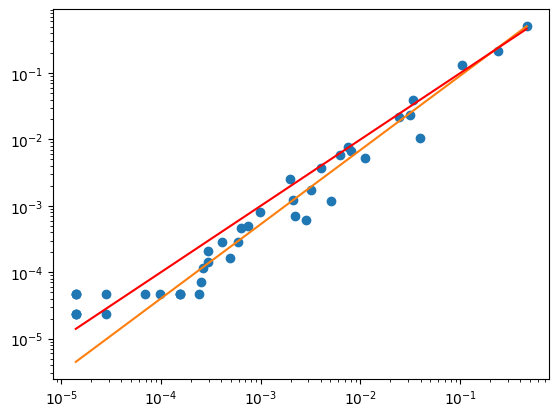

In [9]:
# wait! same with relative frequencies to account for the difference in size of the samples!

# remove neg vals
mask = (col1 > 0) & (col2 > 0)
pos_col1 = col1[mask]
pos_col2 = col2[mask]


# fit
params, cov = curve_fit(power_law, rel_col1, rel_col2)
a, b = params

print("a =", a, "b =", b)

# plot
x_fit = np.linspace(min(rel_col1[mask]), max(rel_col1), 100)
y_fit = power_law(x_fit, a, b)

plt.loglog(rel_col1, rel_col2, 'o')
plt.loglog(x_fit, y_fit)
plt.loglog(x_fit, x_fit, color='red')
plt.show()

[33139 16900  7516  2815  2415  2241  1755   785   576   542   445   361
   286   230   205   157   149   141    71    53    45    42    35    29
    21    21    19    18    17    16    11    11    11     9     7     5
     5     4     3     3]
[1e-08, 1.00000001, 2.00000001, 3.00000001, 4.00000001, 5.00000001, 6.00000001, 7.00000001, 8.00000001, 9.00000001, 10.00000001, 11.00000001, 12.00000001, 13.00000001, 14.00000001, 15.00000001, 16.00000001, 17.00000001, 18.00000001, 19.00000001, 20.00000001, 21.00000001, 22.00000001, 23.00000001, 24.00000001, 25.00000001, 26.00000001, 27.00000001, 28.00000001, 29.00000001, 30.00000001, 31.00000001, 32.00000001, 33.00000001, 34.00000001, 35.00000001, 36.00000001, 37.00000001, 38.00000001, 39.00000001]
a = 135761.67737900547 b = -2.528379519871263


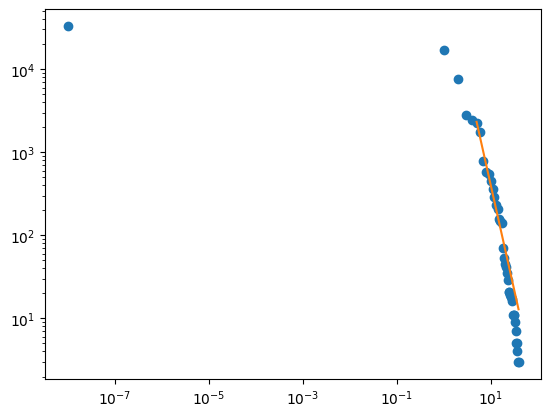

In [10]:
# ATTEMPT AT DOING INDIVIDUAL POWER LAW FITS FOR BOTH SAMPLES
# zipf law
def zipf_law(x, a, b):
    return (x+b)**a
# offset pl
def offset_pow_law(x, a, b,c):
    return a*x**b +c

# remove neg vals
# tallem la cua
mask = (col1 > 2)
pos_col1 = col1[mask]
pos_col1= - np.sort(-pos_col1)
print(pos_col1)
rank_col1 = [i+0.00000001 for i in range(len(pos_col1))]
#to do: provar lo q diu el chatgpt xd

print(rank_col1)
# fit
params, cov = curve_fit(power_law,  rank_col1[5:], pos_col1[5:])
a, b = params

print("a =", a, "b =", b)

# plot the line
x_fit = np.linspace(min(rank_col1[5:]), max(rank_col1), 100)
y_fit = power_law(x_fit, a, b)

plt.semilogy(rank_col1, pos_col1, 'o')
plt.semilogy(x_fit, y_fit)
plt.semilogx()
plt.show()


In [11]:
#pip install powerlaw

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 33/33 [00:00<00:00, 1730.39it/s]

[33139 16900  7516  2815  2415  2241  1755   785   576   542   445   361
   286   230   205   157   149   141    71    53    45    42    35    29
    21    21    19    18    17    16    11    11    11     9     7     5
     5     4     3     3]
alpha = -1.535112876374165 beta = 16899.999831
141.0


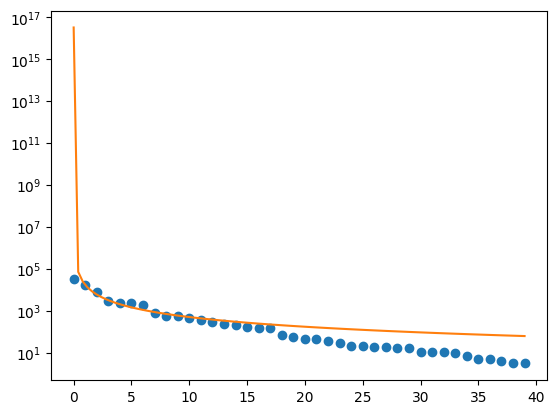

<Axes: >

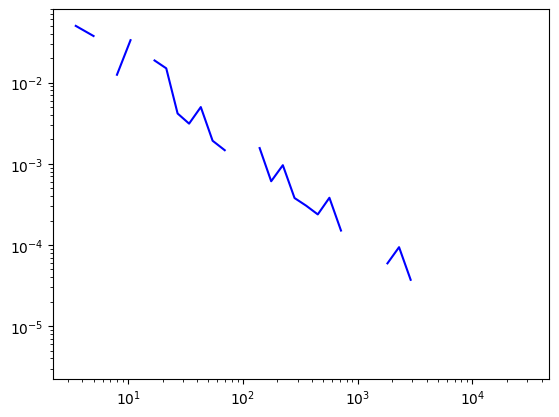

In [12]:
import powerlaw

fit = powerlaw.Fit(pos_col1)
print(pos_col1)
alpha= -fit.alpha
beta= pos_col1[1]/rank_col1[1]
print("alpha =", alpha, "beta =", beta)
print(fit.xmin)


x_fit1 = np.linspace(min(rank_col1), max(rank_col1), 100)
y_fit1 = power_law(x_fit1, beta, alpha)
#print("x_fit1 =", x_fit1, y_fit1)
plt.semilogy(rank_col1, pos_col1, 'o')
plt.semilogy(x_fit1, y_fit1)

plt.show()


powerlaw.plot_pdf(pos_col1, color ='b')

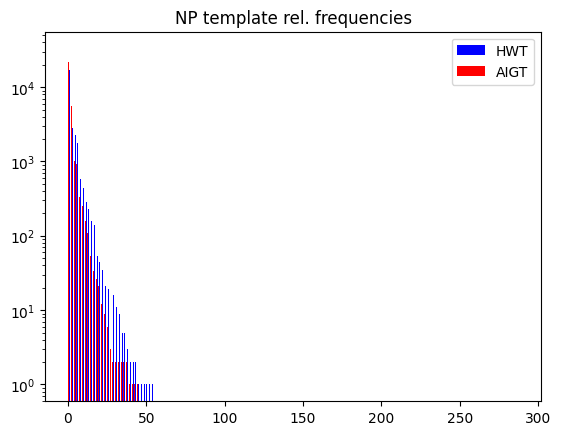

In [13]:
# PLOTTING col1 and col2

mask = (col1 >= 0) | (col2 >= 0)

pos_rel_col1 = rel_col1[mask]
pos_rel_col2 = rel_col2[mask]
col1s = - np.sort(-col1)
col2s = - np.sort(-col2)

rank_col1 = [i+0.00000001 for i in range(len(pos_rel_col1))]


barWidth = 0.35
br1 = np.arange(len(rank_col1))
br2 = [x + barWidth for x in br1]


plt.title("NP template rel. frequencies")
plt.bar(br1, col1s, width= barWidth, color='b', label='HWT')
plt.bar(br2, col2s, width= barWidth, color='r', label='AIGT')
plt.legend( loc='best')
plt.semilogy()
plt.show()

In [14]:
# SVO graphic

SVO1=np.array([5748, 120, 40, 2, 2, 1])
SVO2=np.array([3750,6, 2, 2, 0,0])

rel_SVO1= SVO1*(1/5913)
rel_SVO2= SVO2*(1/3760)

labs=["SVO","OVS","VOS","OSV","VSO","SOV"]

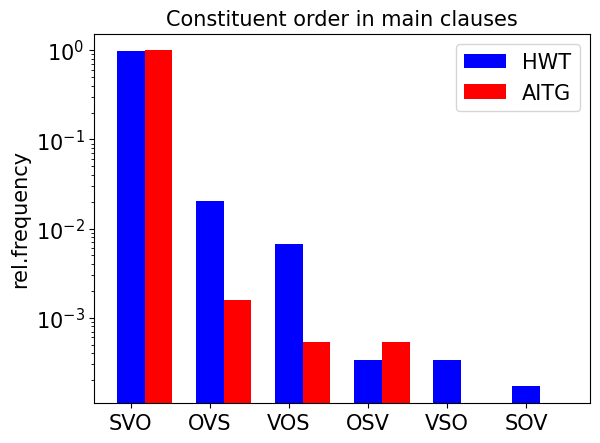

In [15]:
barWidth = 0.35
br1 = np.arange(len(SVO1))
br2 = [x + barWidth for x in br1]
plt.title("Constituent order in main clauses", fontsize=15)
plt.bar(labs,rel_SVO1, width= barWidth, color='b', label='HWT')
plt.bar(br2,rel_SVO2, width= barWidth, color='r', label='AITG')

#plt.semilogy(labs, [0.0352]*6, color='y' , linestyle='--')

plt.ylabel("rel.frequency", fontsize=15)
plt.legend( loc='best', fontsize=15)

plt.xticks(labs, fontsize=15)
plt.yticks(fontsize=15)
plt.semilogy()
plt.show()

In [16]:

# ENTROPY CALCULATIONS


np.random.seed(0)

#rng = np.random.default_rng(42)

group_a = np.repeat(np.arange(len(col1)), col1)
group_b = np.repeat(np.arange(len(col2)), col2)

def statistic(x, y):
    """
    Calculates the absolute difference in Shannon entropy.
    We estimate the probability distribution using histograms.
    """
    # Create bins to turn continuous data into discrete distributions
    #bins = np.histogram_bin_edges(np.concatenate([x, y]), bins=20)

    bins = np.arange(0, len(col1)+1)

    hist_x, _ = np.histogram(x, bins=bins, density=True)
    hist_y, _ = np.histogram(y, bins=bins, density=True)
    #print(hist_x)

    # Calculate Shannon Entropy
    # Note: entropy() handles normalization automatically
    ent_x = entropy(hist_x)
    ent_y = entropy(hist_y)
    #print("ent_x",ent_x, "ent_y",ent_y)
    return ent_x - ent_y



In [17]:
# 2. Run the Permutation Test
res = permutation_test(
    (group_a, group_b),
    statistic,
    permutation_type='independent',
    n_resamples=999,
    vectorized= False,
    alternative='two-sided'
)

print(f"Observed Difference: {res.statistic:.4f}")
print(f"P-value: {res.pvalue:.4f}")
print("actual value:", )

Observed Difference: 0.1921
P-value: 0.0020
actual value:


In [18]:
# proof that entropy converges
import random

i=10
hist_a, _ =  np.histogram(random.choices(group_a, k=10+i*1000), bins=288, density=True)
#print(hist_a)
print(np.histogram(random.choices(group_a, k=10+i*100), bins=288, density=True)[0])

ent_a= [entropy(np.histogram(random.choices(group_a, k=10+i*100), bins=288, density=True)[0]) for i in range(700)]
ent_b= [entropy(np.histogram(random.choices(group_b, k=10+i*100), bins=288, density=True)[0]) for i in range(420)]




[0.44506288 0.00192668 0.         0.06743377 0.         0.00385336
 0.         0.0558737  0.         0.00192668 0.         0.00192668
 0.         0.         0.         0.00385336 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.0096334  0.
 0.         0.         0.         0.         0.00192668 0.
 0.00385336 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.    

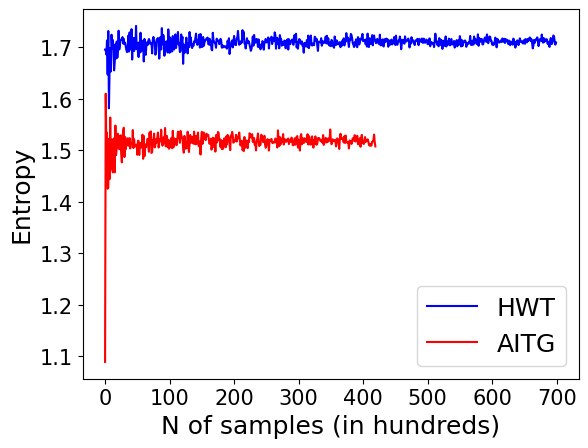

In [19]:
plt.plot(ent_a, color='b', label='HWT')
plt.plot(ent_b, color='r', label='AITG')
plt.xlabel("N of samples (in hundreds)", fontsize=18)
plt.ylabel("Entropy", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend( loc='best', fontsize=18)
plt.show()
